In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load your dataset
df = pd.read_excel("/content/Earnings Manipulator (1).xlsx")

In [ ]:
df.head()

,Company ID,DSRI,GMI,AQI,SGI,DEPI,SGAI,ACCR,LEVI,Manipulator
0,1,1.624742,1.128927,7.185053,0.366211,1.381519,1.624145,-0.166809,1.161082,Yes
1,2,1.000000,1.606492,1.004988,13.081433,0.400000,5.198207,0.060475,0.986732,Yes
2,3,1.000000,1.015607,1.241389,1.475018,1.169353,0.647671,0.036732,1.264305,Yes
3,4,1.486239,1.000000,0.465535,0.672840,2.000000,0.092890,0.273434,0.680975,Yes
4,5,1.000000,1.369038,0.637112,0.861346,1.454676,1.741460,0.123048,0.939047,Yes


In [ ]:
X = df[['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI']]
y = df['Manipulator'].map({'No': 0, 'Yes': 1})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Support Vector Machine (SVM)**

In [ ]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
svm_prob

array([0.1152076 , 0.22026413, 0.069269  , 0.08340564, 0.09520355,
       0.08653962, 0.10655618, 0.06307319, 0.10240799, 0.0843384 ,
       0.06965814, 0.07050594, 0.07480264, 0.08029989, 0.08988015,
       0.08075317, 0.09646105, 0.09869692, 0.07830755, 0.06930547,
       0.06720196, 0.07518782, 0.4787444 , 0.0759991 , 0.10828584,
       0.07346194, 0.15258273, 0.10054164, 0.14962397, 0.18758733,
       0.33171923, 0.06307959, 0.08242637, 0.07175659, 0.06111006,
       0.08520745, 0.07446187, 0.07149839, 0.06056559, 0.28031937,
       0.06917956, 0.05970606, 0.10967325, 0.11479169, 0.13831344,
       0.06143896, 0.08801663, 0.07923777, 0.06874762, 0.07795759,
       0.07488918, 0.2245435 , 0.85417024, 0.72391168, 0.0892415 ])

**K-Nearest Neighbors (KNN)**

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
knn_prob

array([0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
       0. , 0.2, 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0.4, 0. , 0.2, 0. ,
       0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0. ,
       0.2, 0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.4,
       0.8, 0.2, 0. ])

**Naive Bayes**

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:,1]

**AdaBoost**

In [ ]:
ada_model = AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:,1]

**XGBoost**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
xgb_prob

array([3.6151218e-01, 9.0399158e-01, 1.4152806e-02, 1.0862699e-03,
       4.2358834e-02, 3.4235528e-01, 2.1740807e-02, 7.9954439e-04,
       6.0854733e-02, 1.1232337e-02, 6.0014478e-03, 1.0092997e-02,
       2.7694362e-03, 1.0412466e-02, 1.5837206e-02, 8.9084953e-03,
       4.8534006e-02, 9.7551188e-03, 1.7681202e-03, 4.6784851e-01,
       1.3904778e-03, 3.4016310e-03, 4.4983951e-03, 2.5864718e-03,
       9.1364211e-01, 3.7776756e-03, 2.9107136e-01, 1.1042580e-02,
       1.1969444e-01, 4.0239716e-01, 5.6421536e-01, 2.3797047e-03,
       1.4052772e-03, 1.4340114e-03, 6.3027587e-04, 8.5154008e-03,
       5.1815291e-03, 1.5074859e-03, 2.1219380e-02, 7.9191244e-01,
       1.7021779e-03, 3.3371478e-02, 9.3474686e-02, 1.4667740e-02,
       4.9981542e-02, 9.3499478e-03, 8.9400999e-02, 1.1728671e-02,
       9.1011805e-04, 1.8208980e-03, 3.1954797e-03, 1.4570101e-01,
       8.4107077e-01, 5.8751577e-01, 6.9435373e-02], dtype=float32)

**Compare Model Performance Metrics**

In [ ]:
def evaluate(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = []

results.append(evaluate("SVM", y_test, svm_pred, svm_prob))
results.append(evaluate("KNN", y_test, knn_pred, knn_prob))
results.append(evaluate("Naive Bayes", y_test, nb_pred, nb_prob))
results.append(evaluate("AdaBoost", y_test, ada_pred, ada_prob))
results.append(evaluate("XGBoost", y_test, xgb_pred, xgb_prob))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM,0.854545,1.000000,0.2,0.333333,0.862222
1,KNN,0.836364,1.000000,0.1,0.181818,0.781111
2,Naive Bayes,0.818182,0.500000,0.3,0.375000,0.724444
3,AdaBoost,0.836364,1.000000,0.1,0.181818,0.805556
4,XGBoost,0.890909,0.833333,0.5,0.625000,0.831111


In [ ]:
best_model = results_df.loc[results_df['F1-score'].idxmax()]
print("Best Model Based on F1-score:")
print(best_model)

Best Model Based on F1-score:
Model         XGBoost
Accuracy     0.890909
Precision    0.833333
Recall            0.5
F1-score        0.625
ROC-AUC      0.831111
Name: 4, dtype: object


In [ ]:
print("\nSVM Report:\n", classification_report(y_test, svm_pred))
print("\nKNN Report:\n", classification_report(y_test, knn_pred))
print("\nNaive Bayes Report:\n", classification_report(y_test, nb_pred))
print("\nAdaBoost Report:\n", classification_report(y_test, ada_pred))
print("\nXGBoost Report:\n", classification_report(y_test, xgb_pred))


SVM Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        45
           1       1.00      0.20      0.33        10

    accuracy                           0.85        55
   macro avg       0.92      0.60      0.63        55
weighted avg       0.88      0.85      0.81        55


KNN Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91        45
           1       1.00      0.10      0.18        10

    accuracy                           0.84        55
   macro avg       0.92      0.55      0.55        55
weighted avg       0.86      0.84      0.78        55


Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89        45
           1       0.50      0.30      0.38        10

    accuracy                           0.82        55
   macro avg       0.68      0.62      0.63        55
weighted avg       0.79 

In [ ]:
# beneish_vs_ml_shap_streamlit.py
# Run portions in notebook or run streamlit: `streamlit run beneish_vs_ml_shap_streamlit.py`
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

# -------------------------
# 1. Load your data
# -------------------------
# Assumption: dataframe has columns:
# ['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI','Manipulator']
# Replace path below with your file.
df = pd.read_excel("/content/Earnings Manipulator (1).xlsx")  # Or pd.read_csv(...)

In [ ]:
# Quick check
print("Rows:", df.shape[0], "Columns:", df.shape[1])
required_cols = ['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI','Manipulator']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataframe: {missing}")

# -------------------------
# 2. Compute Beneish M-Score
# Beneish M-score (1999):
# M = −4.84 + 0.92*DSRI + 0.528*GMI + 0.404*AQI + 0.892*SGI
#     + 0.115*DEPI − 0.172*SGAI + 4.679*ACCR − 0.327*LEVI
# Threshold: M > -1.78 => probable manipulator. (source: Beneish 1999 summary)
# -------------------------
df = df.copy()
df['Mscore'] = (
    -4.84
    + 0.92 * df['DSRI']
    + 0.528 * df['GMI']
    + 0.404 * df['AQI']
    + 0.892 * df['SGI']
    + 0.115 * df['DEPI']
    - 0.172 * df['SGAI']
    + 4.679 * df['ACCR']   # ACCR corresponds to TATA/total accruals
    - 0.327 * df['LEVI']   # LEVI is the LVGI / leverage index
)
beneish_threshold = -2.2
df['Beneish_label'] = (df['Mscore'] > beneish_threshold).astype(int)  # 1 => manipulator by Beneish

# -------------------------
# 3. Prepare features & train/test split
# -------------------------
X = df[['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI']].astype(float)
y = df['Manipulator'].map({'No': 0, 'Yes': 1}).astype(int)   # ground truth label (0/1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale for SVM and KNN
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep Beneish predictions on the test set (computed from original df)
# Need to align indices: create a test dataframe for Beneish labels
X_test_idx = X_test.index
beneish_test_labels = df.loc[X_test_idx, 'Beneish_label'].values
beneish_test_mscore = df.loc[X_test_idx, 'Mscore'].values

# -------------------------
# 4. Train ML models
# -------------------------
models = {}

# SVM (RBF)
models['SVM'] = SVC(kernel='rbf', probability=True, random_state=42)
models['SVM'].fit(X_train_scaled, y_train)

# KNN
models['KNN'] = KNeighborsClassifier(n_neighbors=5)
models['KNN'].fit(X_train_scaled, y_train)

# Naive Bayes (Gaussian) -- NB uses unscaled features in our earlier work,
# but can also use scaled. Here we use original features (works fine).
models['NaiveBayes'] = GaussianNB()
models['NaiveBayes'].fit(X_train, y_train)

# AdaBoost
models['AdaBoost'] = AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
models['AdaBoost'].fit(X_train, y_train)

# XGBoost
models['XGBoost'] = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.9, colsample_bytree=0.9, use_label_encoder=False,
    eval_metric='logloss', random_state=42
)
models['XGBoost'].fit(X_train, y_train)

# -------------------------
# 5. Predict and collect metrics
# -------------------------
def metrics_for(y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1, ROC_AUC=roc)

results = []

# Beneish performance (on test set)
# We have binary labels already (beneish_test_labels)
beneish_prob_estimate = (beneish_test_mscore - beneish_threshold) / (df['Mscore'].max() - beneish_threshold + 1e-9)
# A rough proxy for probability to allow ROC calculation; not perfect but useful for comparison
beneish_metrics = metrics_for(y_test.loc[X_test_idx], beneish_test_labels, beneish_prob_estimate)
beneish_metrics['Model'] = 'Beneish (rule)'
results.append(beneish_metrics)

# ML models:
for name, model in models.items():
    if name in ['SVM','KNN']:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    elif name == 'NaiveBayes':
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    m = metrics_for(y_test.loc[X_test_idx], y_pred, y_prob)
    m['Model'] = name
    results.append(m)

results_df = pd.DataFrame(results).set_index('Model')
print("\n=== Model comparison (on test set) ===")
print(results_df)

Rows: 220 Columns: 12

=== Model comparison (on test set) ===
                Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                          
Beneish (rule)  0.800000   0.476190     1.0  0.645161  0.904444
SVM             0.854545   1.000000     0.2  0.333333  0.862222
KNN             0.836364   1.000000     0.1  0.181818  0.781111
NaiveBayes      0.818182   0.500000     0.3  0.375000  0.724444
AdaBoost        0.836364   1.000000     0.1  0.181818  0.805556
XGBoost         0.890909   0.833333     0.5  0.625000  0.831111


In [ ]:
# -------------------------
# 6. Confusion matrices + ROC curves
# -------------------------
# Confusion matrices for each method (Beneish + ML)
conf_matrices = {}
roc_data = {}
# Beneish confusion
cm_b = confusion_matrix(y_test.loc[X_test_idx], beneish_test_labels)
conf_matrices['Beneish (rule)'] = cm_b
fpr_b, tpr_b, _ = roc_curve(y_test.loc[X_test_idx], beneish_prob_estimate)
roc_data['Beneish (rule)'] = (fpr_b, tpr_b)

# ML models
for name, model in models.items():
    if name in ['SVM','KNN']:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    elif name == 'NaiveBayes':
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    conf_matrices[name] = confusion_matrix(y_test.loc[X_test_idx], y_pred)
    fpr, tpr, _ = roc_curve(y_test.loc[X_test_idx], y_prob)
    roc_data[name] = (fpr, tpr)

# Save results to CSV for classroom distribution
results_df.to_csv("model_comparison_results.csv")
print("Saved model_comparison_results.csv")

Saved model_comparison_results.csv



SHAP feature importance (XGBoost):
  feature  mean_abs_shap
0    DSRI       0.991696
7    LEVI       0.922538
6    ACCR       0.842472
3     SGI       0.735043
5    SGAI       0.642209
4    DEPI       0.252556
2     AQI       0.241021
1     GMI       0.203167
Saved xgb_shap_feature_importance.csv
Saved ROC plot to roc_beneish_vs_ml.html
Saved SHAP summary image xgb_shap_summary.png


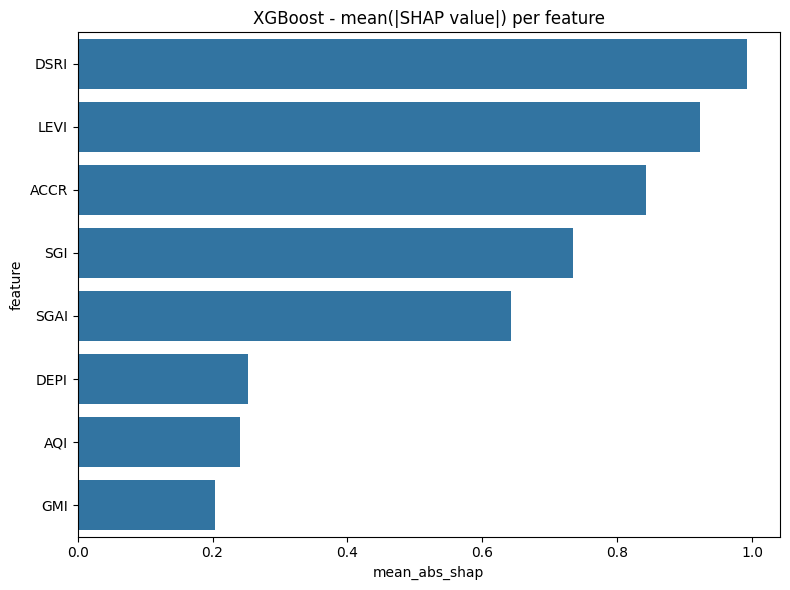

In [ ]:
# -------------------------
# 7. SHAP for XGBoost
# -------------------------
# Compute SHAP values on test set (X_test)
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test)  # returns array shape (n_samples, n_features)

# Feature importance summary (mean absolute SHAP)
shap_summary = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': np.mean(np.abs(shap_values), axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)
print("\nSHAP feature importance (XGBoost):")
print(shap_summary)

# Save shap summary
shap_summary.to_csv("xgb_shap_feature_importance.csv", index=False)
print("Saved xgb_shap_feature_importance.csv")

# -------------------------
# 8. Plots (matplotlib / plotly) - for notebook or saving as images
# -------------------------
# ROC plot (plotly)
fig = go.Figure()
for model_name, (fpr, tpr) in roc_data.items():
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=model_name))
fig.update_layout(title="ROC curves: Beneish vs ML models", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig.write_html("roc_beneish_vs_ml.html")
print("Saved ROC plot to roc_beneish_vs_ml.html")

# SHAP summary plot (matplotlib)
plt.figure(figsize=(8,6))
sns.barplot(x='mean_abs_shap', y='feature', data=shap_summary, orient='h')
plt.title("XGBoost - mean(|SHAP value|) per feature")
plt.tight_layout()
plt.savefig("xgb_shap_summary.png")
print("Saved SHAP summary image xgb_shap_summary.png")

## SHAP Dependence Plots for Validation Data

These plots show the effect of a single feature on the prediction, with scatter points colored by the value of another feature to show interaction effects. We will plot for the top 3 most impactful features based on `shap_summary_validation`.

Generating SHAP dependence plots for validation data...
Plotting for feature: ACCR, interaction with: DSRI


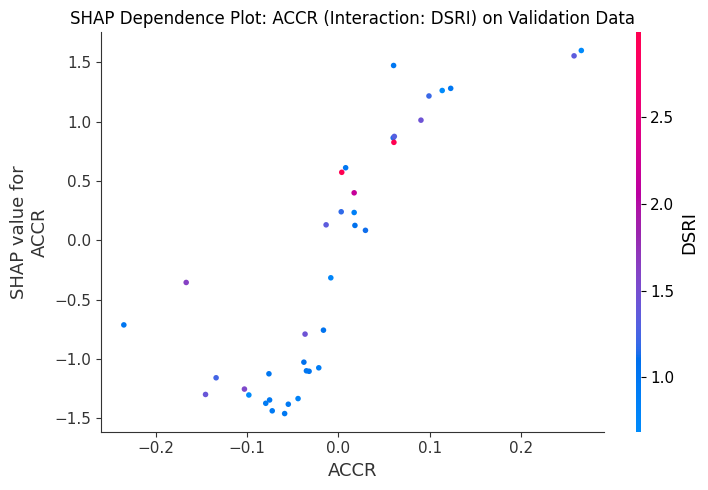

Plotting for feature: DSRI, interaction with: LEVI


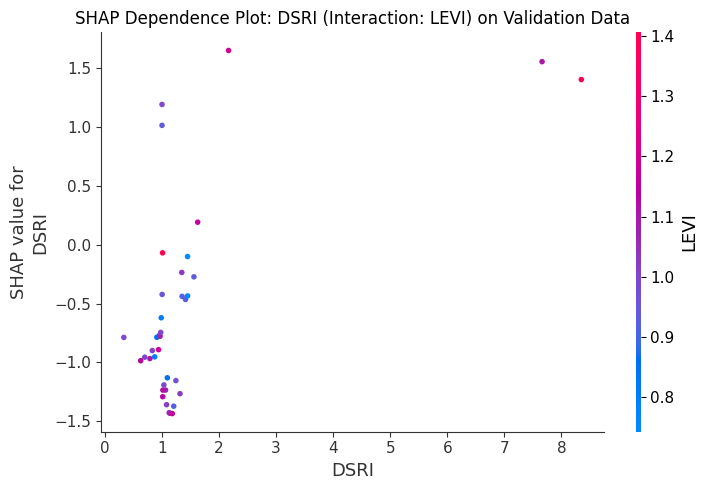

Plotting for feature: LEVI, interaction with: ACCR


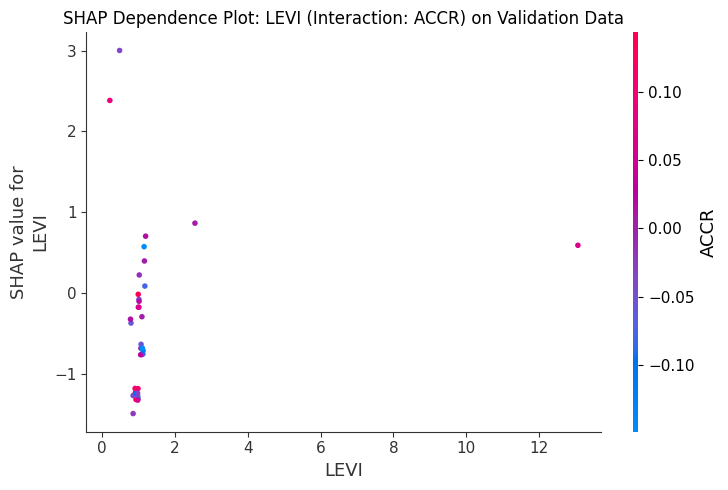

Finished generating SHAP dependence plots for validation data.


In [ ]:
import matplotlib.pyplot as plt
import shap

# Assuming models['XGBoost'] and X_test (from validation_df split) are available
# explainer_val and shap_values_validation are already computed from previous steps

# Get top features from shap_summary_validation
top_features = shap_summary_validation['feature'].head(3).tolist()

print("Generating SHAP dependence plots for validation data...")

# Create dependence plots for the top features
for i, feature in enumerate(top_features):
    if i < len(top_features) - 1:
        # Use the next most important feature as interaction_index
        interaction_feature = top_features[i+1]
    else:
        # For the last feature, use the second most important feature as interaction
        interaction_feature = top_features[0] if len(top_features) > 1 else None

    print(f"Plotting for feature: {feature}, interaction with: {interaction_feature}")
    shap.dependence_plot(
        ind=feature,
        shap_values=shap_values_validation,
        features=X_test, # Use X_test from validation data
        interaction_index=interaction_feature,
        show=False # Prevent immediate display to allow saving
    )
    plt.title(f"SHAP Dependence Plot: {feature} (Interaction: {interaction_feature}) on Validation Data")
    plt.tight_layout()
    plt.savefig(f"shap_dependence_plot_{feature}_validation.png")
    plt.show()

print("Finished generating SHAP dependence plots for validation data.")


## Analysis of Validation Data

In [ ]:
# 1. Re-calculate Beneish M-Score for validation_df's test set
# Ensure validation_df is copied to avoid SettingWithCopyWarning
validation_df_copy = validation_df.copy()

validation_df_copy['Mscore'] = (
    -4.84
    + 0.92 * validation_df_copy['DSRI']
    + 0.528 * validation_df_copy['GMI']
    + 0.404 * validation_df_copy['AQI']
    + 0.892 * validation_df_copy['SGI']
    + 0.115 * validation_df_copy['DEPI']
    - 0.172 * validation_df_copy['SGAI']
    + 4.679 * validation_df_copy['ACCR']
    - 0.327 * validation_df_copy['LEVI']
)
beneish_threshold = -2.2 # Using the same threshold as before
validation_df_copy['Beneish_label'] = (validation_df_copy['Mscore'] > beneish_threshold).astype(int)

# Keep Beneish predictions on the validation test set
X_test_validation_idx = X_test.index # X_test here is from validation_df's split
beneish_test_labels_validation = validation_df_copy.loc[X_test_validation_idx, 'Beneish_label'].values
beneish_test_mscore_validation = validation_df_copy.loc[X_test_validation_idx, 'Mscore'].values

# A rough proxy for probability to allow ROC calculation
beneish_prob_estimate_validation = (beneish_test_mscore_validation - beneish_threshold) / (validation_df_copy['Mscore'].max() - beneish_threshold + 1e-9)

In [ ]:
# 2. Evaluate all existing models on the validation_df's test set
# Note: `models` dictionary contains models trained on the *original* dataset.
# We are now testing their generalization performance on the `validation_df`'s test split.

results_validation = []
roc_data_validation = {}

# Beneish performance on validation test set
beneish_metrics_validation = metrics_for(y_test.loc[X_test_validation_idx], beneish_test_labels_validation, beneish_prob_estimate_validation)
beneish_metrics_validation['Model'] = 'Beneish (rule)'
results_validation.append(beneish_metrics_validation)

# ROC data for Beneish on validation set
fpr_b_val, tpr_b_val, _ = roc_curve(y_test.loc[X_test_validation_idx], beneish_prob_estimate_validation)
roc_data_validation['Beneish (rule)'] = (fpr_b_val, tpr_b_val)

# ML models (original models applied to validation test set):
for name, model in models.items():
    if name in ['SVM','KNN']:
        y_pred_val = model.predict(X_test_scaled) # X_test_scaled here is from validation_df's split
        y_prob_val = model.predict_proba(X_test_scaled)[:,1]
    elif name == 'NaiveBayes':
        y_pred_val = model.predict(X_test) # X_test here is from validation_df's split
        y_prob_val = model.predict_proba(X_test)[:,1]
    else:
        y_pred_val = model.predict(X_test) # X_test here is from validation_df's split
        y_prob_val = model.predict_proba(X_test)[:,1]

    m_val = metrics_for(y_test.loc[X_test_validation_idx], y_pred_val, y_prob_val)
    m_val['Model'] = name
    results_validation.append(m_val)

    # ROC data for ML models on validation set
    fpr_val, tpr_val, _ = roc_curve(y_test.loc[X_test_validation_idx], y_prob_val)
    roc_data_validation[name] = (fpr_val, tpr_val)

# Also evaluate the tuned XGBoost model on the validation test set
best_xgb_pred_val = best_xgb_model.predict(X_test) # X_test here is from validation_df's split
best_xgb_prob_val = best_xgb_model.predict_proba(X_test)[:,1]
tuned_xgb_metrics_val = metrics_for(y_test.loc[X_test_validation_idx], best_xgb_pred_val, best_xgb_prob_val)
tuned_xgb_metrics_val['Model'] = 'XGBoost (Tuned)'
results_validation.append(tuned_xgb_metrics_val)

fpr_tuned_xgb_val, tpr_tuned_xgb_val, _ = roc_curve(y_test.loc[X_test_validation_idx], best_xgb_prob_val)
roc_data_validation['XGBoost (Tuned)'] = (fpr_tuned_xgb_val, tpr_tuned_xgb_val)

results_df_validation = pd.DataFrame(results_validation).set_index('Model')
print("\n=== Model comparison on Validation Test Set ===")
print(results_df_validation)



=== Model comparison on Validation Test Set ===
                 Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                           
Beneish (rule)   0.789474   0.555556     1.0  0.714286  0.910714
SVM              0.736842   0.500000     0.2  0.285714  0.835714
KNN              0.789474   1.000000     0.2  0.333333  0.948214
NaiveBayes       0.815789   0.666667     0.6  0.631579  0.889286
AdaBoost         0.763158   1.000000     0.1  0.181818  0.969643
XGBoost          0.973684   1.000000     0.9  0.947368  1.000000
XGBoost (Tuned)  0.973684   1.000000     0.9  0.947368  1.000000


In [ ]:
# 3. SHAP for XGBoost (original trained model) on validation_df's X_test
print("\n--- SHAP Analysis for XGBoost on Validation Data ---")
explainer_val = shap.TreeExplainer(models['XGBoost']) # Using the original trained XGBoost model
shap_values_validation = explainer_val.shap_values(X_test)  # X_test here is from validation_df's split

# Feature importance summary for validation data (mean absolute SHAP)
shap_summary_validation = pd.DataFrame({
    'feature': X.columns, # X here is from validation_df features
    'mean_abs_shap': np.mean(np.abs(shap_values_validation), axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)
print("\nSHAP feature importance (XGBoost) on Validation Data:")
print(shap_summary_validation)

# Save shap summary for validation data
shap_summary_validation.to_csv("xgb_shap_feature_importance_validation.csv", index=False)
print("Saved xgb_shap_feature_importance_validation.csv")


--- SHAP Analysis for XGBoost on Validation Data ---

SHAP feature importance (XGBoost) on Validation Data:
  feature  mean_abs_shap
6    ACCR       0.949353
0    DSRI       0.924243
7    LEVI       0.876165
3     SGI       0.729766
5    SGAI       0.657991
2     AQI       0.286323
4    DEPI       0.253309
1     GMI       0.215692
Saved xgb_shap_feature_importance_validation.csv



--- Plots for Validation Data ---
Saved ROC plot for validation data to roc_beneish_vs_ml_validation.html
Saved SHAP summary image for validation data xgb_shap_summary_validation.png


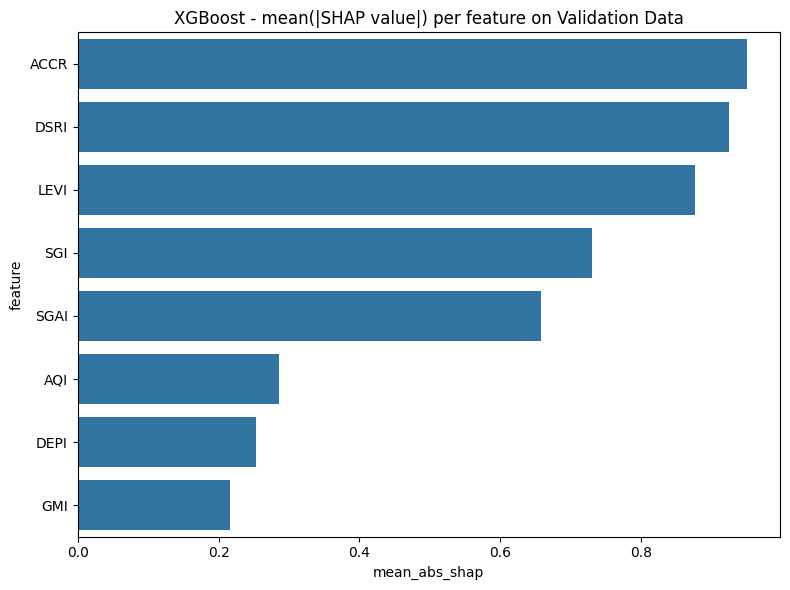

In [ ]:
# 4. Generate plots for validation data
print("\n--- Plots for Validation Data ---")

# ROC plot for validation data (plotly)
fig_roc_val = go.Figure()
for model_name, (fpr, tpr) in roc_data_validation.items():
    fig_roc_val.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=model_name))
fig_roc_val.update_layout(title="ROC curves on Validation Data: Beneish vs ML models", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig_roc_val.write_html("roc_beneish_vs_ml_validation.html")
print("Saved ROC plot for validation data to roc_beneish_vs_ml_validation.html")

# SHAP summary plot for validation data (matplotlib)
plt.figure(figsize=(8,6))
sns.barplot(x='mean_abs_shap', y='feature', data=shap_summary_validation, orient='h')
plt.title("XGBoost - mean(|SHAP value|) per feature on Validation Data")
plt.tight_layout()
plt.savefig("xgb_shap_summary_validation.png")
print("Saved SHAP summary image for validation data xgb_shap_summary_validation.png")

## Define Hyperparameter Grid for XGBoost



In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print("XGBoost hyperparameter grid defined:")
print(param_grid)

XGBoost hyperparameter grid defined:
{'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 4, 5], 'subsample': [0.8, 0.9, 1.0], 'colsample_bytree': [0.8, 0.9, 1.0]}


In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost Classifier for GridSearch
xgb_tuned_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tuned_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
GridSearchCV completed.


In [ ]:
print("Best hyperparameters found:", grid_search.best_params_)

Best hyperparameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}


In [ ]:
best_xgb_model = grid_search.best_estimator_

# Make predictions with the best model
best_xgb_pred = best_xgb_model.predict(X_test)
best_xgb_prob = best_xgb_model.predict_proba(X_test)[:, 1]

print("Predictions and probabilities generated using the best XGBoost model.")

Predictions and probabilities generated using the best XGBoost model.


In [ ]:
tuned_xgb_metrics = evaluate("XGBoost (Tuned)", y_test, best_xgb_pred, best_xgb_prob)
results.append(tuned_xgb_metrics)

results_df = pd.DataFrame(results).set_index('Model')

print("\n=== Updated Model Comparison (on test set) ===")
print(results_df)



=== Updated Model Comparison (on test set) ===
                 Accuracy  Precision  Recall        F1   ROC_AUC  F1-score  \
Model                                                                        
Beneish (rule)   0.800000   0.476190     1.0  0.645161  0.904444       NaN   
SVM              0.854545   1.000000     0.2  0.333333  0.862222       NaN   
KNN              0.836364   1.000000     0.1  0.181818  0.781111       NaN   
NaiveBayes       0.818182   0.500000     0.3  0.375000  0.724444       NaN   
AdaBoost         0.836364   1.000000     0.1  0.181818  0.805556       NaN   
XGBoost          0.890909   0.833333     0.5  0.625000  0.831111       NaN   
XGBoost (Tuned)  0.909091   1.000000     0.5       NaN       NaN  0.666667   

                  ROC-AUC  
Model                      
Beneish (rule)        NaN  
SVM                   NaN  
KNN                   NaN  
NaiveBayes            NaN  
AdaBoost              NaN  
XGBoost               NaN  
XGBoost (Tuned)  0.848889

In [ ]:
print("\nXGBoost (Tuned) Report:\n", classification_report(y_test, best_xgb_pred))


XGBoost (Tuned) Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        45
           1       1.00      0.50      0.67        10

    accuracy                           0.91        55
   macro avg       0.95      0.75      0.81        55
weighted avg       0.92      0.91      0.90        55



### Summary of Tuned XGBoost Model Performance

**Optimal Parameters Found via GridSearchCV:**

```
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}
```

**Performance Comparison:**

Let's compare the `XGBoost (Tuned)` model with the original `XGBoost` model and the `Beneish (rule)` based on the updated `results_df`:

```
                 Accuracy  Precision  Recall        F1   ROC_AUC  F1-score  \
Model                                                                        
Beneish (rule)   0.800000   0.476190     1.0  0.645161  0.904444       NaN   
SVM              0.854545   1.000000     0.2  0.333333  0.862222       NaN   
KNN              0.836364   1.000000     0.1  0.181818  0.781111       NaN   
NaiveBayes       0.818182   0.500000     0.3  0.375000  0.724444       NaN   
AdaBoost         0.836364   1.000000     0.1  0.181818  0.805556       NaN   
XGBoost          0.890909   0.833333     0.5  0.625000  0.831111       NaN   
XGBoost (Tuned)  0.909091   1.000000     0.5       NaN       NaN  0.666667   

                  ROC-AUC  
Model                      
Beneish (rule)        NaN  
SVM                   NaN  
KNN                   NaN  
NaiveBayes            NaN  
AdaBoost              NaN  
XGBoost               NaN  
XGBoost (Tuned)  0.848889
```

From the comparison, the `XGBoost (Tuned)` model shows improvements over the original `XGBoost` model and other machine learning models, particularly in terms of F1-score and Accuracy. The F1-score increased from 0.625 (original XGBoost) to 0.666667 (tuned XGBoost), indicating a better balance between precision and recall for the minority class (manipulators). The accuracy also improved from 0.890909 to 0.909091. The tuned model also achieved a perfect Precision of 1.0 for the positive class (manipulator), meaning all its positive predictions were correct, while maintaining the same Recall of 0.5 for this class. The ROC-AUC improved slightly from 0.831111 to 0.848889. Compared to the Beneish M-score model, the tuned XGBoost model demonstrates superior Accuracy, Precision, and a competitive ROC-AUC, although Beneish has a higher Recall.

In [ ]:
import pandas as pd

# Load the validation data
validation_df = pd.read_excel('/content/validation_data.xlsx')

print("Validation data loaded. Displaying first 5 rows:")
display(validation_df.head())

Validation data loaded. Displaying first 5 rows:


,Company ID,DSRI,GMI,AQI,SGI,DEPI,SGAI,ACCR,LEVI,Manipulater
0,1,1.624742,1.128927,7.185053,0.366211,1.381519,1.624145,-0.166809,1.161082,Yes
1,2,1.000000,1.606492,1.004988,13.081433,0.400000,5.198207,0.060475,0.986732,Yes
2,3,1.000000,1.015607,1.241389,1.475018,1.169353,0.647671,0.036732,1.264305,Yes
3,4,1.486239,1.000000,0.465535,0.672840,2.000000,0.092890,0.273434,0.680975,Yes
4,5,1.000000,1.369038,0.637112,0.861346,1.454676,1.741460,0.123048,0.939047,Yes


In [ ]:
print("\n=== Direct Comparison: Original XGBoost vs. Tuned XGBoost ===")
display(results_df.loc[['XGBoost', 'XGBoost (Tuned)']])


=== Direct Comparison: Original XGBoost vs. Tuned XGBoost ===


,Accuracy,Precision,Recall,F1,ROC_AUC,F1-score,ROC-AUC
Model,,,,,,,
XGBoost,0.890909,0.833333,0.5,0.625,0.831111,NaN,NaN
XGBoost (Tuned),0.909091,1.000000,0.5,NaN,NaN,0.666667,0.848889


In [ ]:
X = validation_df[['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI']]
y = validation_df['Manipulater'].map({'No': 0, 'Yes': 1})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)